
This Colab file uses MIMIC-III Dataset tables. It carries out the following steps

0. Installs the packages for Cox Model and RSF
1. Loads the prepared csv file that has the cohort data for adult female patients admitted to the ICU who were diagnosed with
blood-related diseases, identified using ICD-9 codes 280–289. Only the first ICU
stay per hospital admission was considered.
2. Implements the following Baseline Classification Models:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting
   - XGBoost
to predict binary mortality.
3. Steps for Mortality Rate Calculation
4. Bar chart visaulization of Mortality trends
5. Data conversion for time to event format for Survival Analysis.
6. Cox model implementation for Survival Analysis
7. RSF Model implementation for Survival Analysis with hyper tuning
8. Visualization of th model parameters
9. Save the model
10. Dowmload the model

Feature Extraction:
Clinical features were derived from the first 24 hours of ICU admission to avoid
label leakage. These included:
- Vital signs (heart rate statistics: mean, min, max)
- Laboratory values (hemoglobin, hematocrit, glucose)

Outcome Definition:
The primary outcome was in-hospital mortality. For survival analysis, time-to-event
was defined as the duration from ICU admission (intime) to either death (event=1) or discharge (event=0).

Data processing:
- Missing values imputed using median imputation
- Removed Non-numeric identifiers
- Time variables converted to durations (hours)

Modeling Approach:
1. Baseline Classification Models:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting
   - XGBoost
2. Survival Models:
   - Cox Proportional Hazards Model
   - Random Survival Forest (RSF)

Evaluation Metrics:
- Classification: Area Under ROC Curve (AUC), Accuracy
- Survival Models: Concordance Index (C-index)

Hyperparameter Tuning:
Grid search with 3-fold cross-validation was applied to optimize RSF parameters.



In [1]:
# ============================================
# STEP 0: Install Missing packages
# Cox model (lifelines)
# Random Survival Forest (scikit-survival)
# If you get error Restart Session and execute this codeblock again
# ===========================================

!pip install lifelines scikit-survival

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f5bd3f0a186fd2a7c7cc5b81f047b45672c82bc56ff486f6c3bd278a094ff4e8
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ================================================================
# STEP 1: LOAD DATA
# ------------------------------------------------
# Assumes CSV is already generated from BigQuery
# ================================================================
import pandas as pd
import numpy as np

# Execute to load female_blood_disease_icu.csv file that located on your local machine
from google.colab import files
uploaded = files.upload()


Saving female_blood_disease_icu.csv to female_blood_disease_icu.csv


In [3]:
PATH_FEMALE_BLOOD_DISEASE_ICU = 'female_blood_disease_icu.csv'
# Define the file path for the female_blood_disease_icu dataset (stored as a csv file)

df = pd.read_csv('/content/female_blood_disease_icu.csv')

print("Dataset shape:", df.shape)

Dataset shape: (9747, 14)


In [4]:
# ================================================================
# STEP 2: BASELINE ML MODELS (CLASSIFICATION)
# ------------------------------------------------
# PURPOSE:
# - Predict mortality as a binary outcome
# - Provides baseline before survival modeling
# ================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

# Handle missing values
clf_df = df.fillna(df.median(numeric_only=True))

# Define features and target
y_clf = clf_df['mortality']
# Drop Non numeric Columns
X_clf = clf_df.drop(columns=['subject_id','hadm_id','icustay_id','mortality','gender','intime','outtime','deathtime'])

# Train-test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Define models
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

print("\n=== Baseline ML Models ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print(f"{name} -> AUC: {roc_auc_score(y_test, probs):.3f}, Accuracy: {accuracy_score(y_test, preds):.3f}")



=== Baseline ML Models ===
Logistic -> AUC: 0.698, Accuracy: 0.880
RandomForest -> AUC: 0.713, Accuracy: 0.872
GradientBoosting -> AUC: 0.739, Accuracy: 0.880
XGBoost -> AUC: 0.704, Accuracy: 0.875


In [5]:
# ================================================================
# STEP 3: MORTALITY RATE CALCULATION
# ------------------------------------------------
# PURPOSE:
# - Understand dataset distribution
# - Important for clinical interpretation
# ================================================================

# Overall mortality rate
mortality_rate = df['mortality'].mean()
print("\nOverall Mortality Rate:", round(mortality_rate,3))

# Group by ICU duration (proxy for severity)
df['duration_hours'] = (pd.to_datetime(df['outtime']) - pd.to_datetime(df['intime'])).dt.total_seconds()/3600

df['duration_group'] = pd.cut(
    df['duration_hours'],
    bins=[0,24,72,168,10000],
    labels=['<1d','1-3d','3-7d','>7d']
)

mortality_by_group = df.groupby('duration_group')['mortality'].mean()

print("\nMortality by ICU duration group:")
print(mortality_by_group)



Overall Mortality Rate: 0.132

Mortality by ICU duration group:
duration_group
<1d     0.133228
1-3d    0.080916
3-7d    0.147779
>7d     0.242643
Name: mortality, dtype: float64


/tmp/ipykernel_10271/3698361577.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_by_group = df.groupby('duration_group')['mortality'].mean()


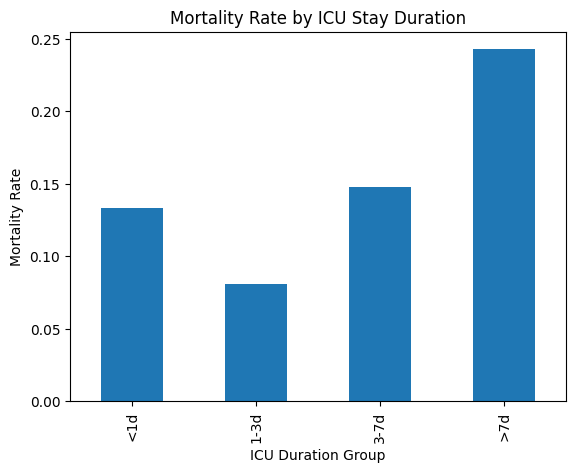

In [6]:
# ================================================================
# STEP 4: VISUALIZATION
# ------------------------------------------------
# PURPOSE:
# - Visualize mortality trends
# ================================================================

import matplotlib.pyplot as plt

plt.figure()
mortality_by_group.plot(kind='bar')
plt.title("Mortality Rate by ICU Stay Duration")
plt.xlabel("ICU Duration Group")
plt.ylabel("Mortality Rate")
plt.show()


In [7]:
# ================================================================
# STEP 5: SURVIVAL ANALYSIS DATASET
# ------------------------------------------------
# PURPOSE:
# - Convert data into time-to-event format
# ================================================================

# Convert timestamps
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])
df['deathtime'] = pd.to_datetime(df['deathtime'])

# Event indicator (1 = death)
df['event'] = df['mortality']

# Duration (time until event or discharge)
df['duration'] = (df['outtime'] - df['intime']).dt.total_seconds()/3600

# If death occurs earlier than discharge
mask = df['deathtime'].notnull()
df.loc[mask, 'duration'] = (
    df.loc[mask, 'deathtime'] - df.loc[mask, 'intime']
).dt.total_seconds()/3600



In [8]:
# ================================================================
# STEP 6: COX MODEL
# ================================================================

from lifelines import CoxPHFitter
import pandas as pd


# Prepare features
X = df.drop(columns=['subject_id','hadm_id','icustay_id','mortality','event','duration','gender', 'intime', 'outtime', 'deathtime'], errors='ignore')
X = X.fillna(X.median(numeric_only=True))

cox_df = X.copy()
cox_df['duration'] = df['duration']
cox_df['event'] = df['event']

# Drop non-numeric columns
cox_df = cox_df.select_dtypes(include=[np.number])

# Ensure duration & event still exist
cox_df['duration'] = df['duration']
cox_df['event'] = df['event']

# Fill missing values
cox_df = cox_df.fillna(0)

# Fit Cox Model
cox = CoxPHFitter()
cox.fit(cox_df, duration_col='duration', event_col='event')

cox.print_summary()


<lifelines.CoxPHFitter: fitted with 9747 total observations, 8462 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 9747
number of events observed = 1285
   partial log-likelihood = -8910.02
         time fit was run = 2026-04-26 01:41:44 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
heart_rate_mean  0.03      1.03      0.00            0.02            0.03                1.02                1.03
heart_rate_min  -0.03      0.97      0.00           -0.03           -0.03                0.97                0.97
heart_rate_max   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hemoglobin       0.01      1.01      0.03           -0.06            0.07                0.95                1.07
hematocrit       0.10      1.11      0.01            0.09            0.12                1.09                1.13
glucose          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
duration_hours  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                 cmp to      z      p  -log2(p)
covariate                                      
heart_rate_mean    0.00   8.18 <0.005     51.70
heart_rate_min     0.00 -17.17 <0.005    217.10
heart_rate_max     0.00   0.11   0.91      0.13
hemoglobin         0.00   0.22   0.83      0.27
hematocrit         0.00  12.87 <0.005    123.42
glucose            0.00   0.21   0.84      0.26
duration_hours     0.00 -22.99 <0.005    386.09
---
Concordance = 0.86
Partial AIC = 17834.04
log-likelihood ratio test = 1207.64 on 7 df
-log2(p) of ll-ratio test = 849.76

The RSF code block initially ran for ~ 5.5 hours to iterate 36 models and retrain.The second run took about 40 mins. It also needs High - RAM settings to execute without crash.

In [9]:
# ================================================================
# STEP 7: RANDOM SURVIVAL FOREST
# ================================================================
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, ParameterGrid
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

# =========================================================
# Step a: Remove invalid rows
# =========================================================
cox_df = cox_df.copy()
cox_df = cox_df[cox_df["duration"] > 0].copy()
cox_df["event"] = cox_df["event"].astype(bool)

# =========================================================
# Step b: Train / Validation / Test split
# =========================================================
train_full_df, test_df = train_test_split(
    cox_df,
    test_size=0.2,
    random_state=42,
    stratify=cox_df["event"]
)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.2,   # 20% of train_full becomes validation
    random_state=42,
    stratify=train_full_df["event"]
)

# =========================================================
# Step c: Build feature matrices
# =========================================================
cols_to_drop = [
    "event", "duration",
    "los_group", "gender",
    "subject_id", "hadm_id", "icustay_id"
]

X_train = train_df.drop(columns=cols_to_drop, errors="ignore")
X_val   = val_df.drop(columns=cols_to_drop, errors="ignore")
X_test  = test_df.drop(columns=cols_to_drop, errors="ignore")

# Keep only numeric columns
X_train = X_train.select_dtypes(include=[np.number]).copy()
X_val   = X_val.select_dtypes(include=[np.number]).copy()
X_test  = X_test.select_dtypes(include=[np.number]).copy()

# =========================================================
# Step d: Handle missing values
# =========================================================
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# =========================================================
# Step e: Align feature columns
# =========================================================
X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Re-align val and test to final train columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# =========================================================
# Step f: Remove constant columns
# =========================================================
constant_cols = X_train.columns[X_train.nunique(dropna=False) <= 1]
if len(constant_cols) > 0:
    X_train = X_train.drop(columns=constant_cols)
    X_val   = X_val.drop(columns=constant_cols, errors="ignore")
    X_test  = X_test.drop(columns=constant_cols, errors="ignore")

# Optional: keep only top-k most variable columns
# Uncomment for very large datasets
# top_k = 200
# variances = X_train.var().sort_values(ascending=False)
# selected_cols = variances.head(top_k).index
# X_train = X_train[selected_cols]
# X_val   = X_val[selected_cols]
# X_test  = X_test[selected_cols]

# Reduce memory usage
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

# =========================================================
# Step g: Create survival targets
# =========================================================
y_train = Surv.from_dataframe("event", "duration", train_df)
y_val   = Surv.from_dataframe("event", "duration", val_df)
y_test  = Surv.from_dataframe("event", "duration", test_df)

print("Train shape:", X_train.shape, "Target length:", len(y_train))
print("Val shape  :", X_val.shape,   "Target length:", len(y_val))
print("Test shape :", X_test.shape,  "Target length:", len(y_test))

# =========================================================
# Step h: Hyperparameter tuning
# =========================================================
#param_grid = {
 #   "n_estimators": [50, 100],
  #  "min_samples_split": [10, 20],
   # "min_samples_leaf": [10, 20],
    #"max_features": ["sqrt"]
#}

param_grid = {
    "n_estimators": [50, 100, 200],   # 3
    "min_samples_split": [10, 20],    # 2
    "min_samples_leaf": [5, 15, 25],  # 3
    "max_features": ["sqrt", "log2"]  # 2
}

best_score = -np.inf
best_params = None
best_model = None
results = []

print("\nStarting hyperparameter tuning...\n")

for i, params in enumerate(ParameterGrid(param_grid), start=1):
    print(f"Model {i}: {params}")
    start_time = time.time()

    rsf = RandomSurvivalForest(
        n_estimators=params["n_estimators"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=-1,
        random_state=42,
        oob_score=True
    )

    rsf.fit(X_train, y_train)

    # Risk scores
    train_risk = rsf.predict(X_train)
    val_risk = rsf.predict(X_val)

    # C-index
    train_cindex = concordance_index_censored(
        y_train["event"], y_train["duration"], train_risk
    )[0]

    val_cindex = concordance_index_censored(
        y_val["event"], y_val["duration"], val_risk
    )[0]

    elapsed = time.time() - start_time

    results.append({
        "n_estimators": params["n_estimators"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "max_features": params["max_features"],
        "train_cindex": train_cindex,
        "val_cindex": val_cindex,
        "oob_score": rsf.oob_score_,
        "time_sec": elapsed
    })

    print(f"  Train C-index: {train_cindex:.4f}")
    print(f"  Val   C-index: {val_cindex:.4f}")
    print(f"  OOB score    : {rsf.oob_score_:.4f}")
    print(f"  Time         : {elapsed:.2f} sec\n")

    if val_cindex > best_score:
        best_score = val_cindex
        best_params = params
        best_model = rsf

# Store tuning results in a dataframe
results_df = pd.DataFrame(results).sort_values(by="val_cindex", ascending=False)

print("\nBest Parameters:")
print(best_params)
print(f"Best Validation C-index: {best_score:.4f}")

print("\nTop 10 tuning results:")
print(results_df.head(10))

# =========================================================
# Step i: Retrain best model on train + validation
# =========================================================
X_train_final = pd.concat([X_train, X_val], axis=0)
train_val_df = pd.concat([train_df, val_df], axis=0)
y_train_final = Surv.from_dataframe("event", "duration", train_val_df)

print("\nRetraining best model on combined train + validation set...")

final_model = RandomSurvivalForest(
    n_estimators=best_params["n_estimators"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    n_jobs=-1,
    random_state=42,
    oob_score=True
)

start_time = time.time()
final_model.fit(X_train_final, y_train_final)
elapsed = time.time() - start_time

print(f"Final model training time: {elapsed:.2f} sec")
print(f"Final OOB score: {final_model.oob_score_:.4f}")

# =========================================================
# Step j: Final evaluation on test set
# =========================================================
train_final_risk = final_model.predict(X_train_final)
test_risk = final_model.predict(X_test)

train_final_cindex = concordance_index_censored(
    y_train_final["event"], y_train_final["duration"], train_final_risk
)[0]

test_cindex = concordance_index_censored(
    y_test["event"], y_test["duration"], test_risk
)[0]

print(f"\nFinal Train C-index: {train_final_cindex:.4f}")
print(f"Final Test  C-index: {test_cindex:.4f}")


Train shape: (6228, 7) Target length: 6228
Val shape  : (1557, 7) Target length: 1557
Test shape : (1947, 7) Target length: 1947

Starting hyperparameter tuning...

Model 1: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 50}
  Train C-index: 0.9461
  Val   C-index: 0.7914
  OOB score    : 0.8186
  Time         : 21.32 sec

Model 2: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
  Train C-index: 0.9474
  Val   C-index: 0.7995
  OOB score    : 0.8282
  Time         : 42.55 sec

Model 3: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
  Train C-index: 0.9491
  Val   C-index: 0.8088
  OOB score    : 0.8373
  Time         : 84.26 sec

Model 4: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 50}
  Train C-index: 0.9308
  Val   C-index: 0.8179
  OOB score    : 0.8198
  Time         : 21.54 sec

Model 5: {'max_features':

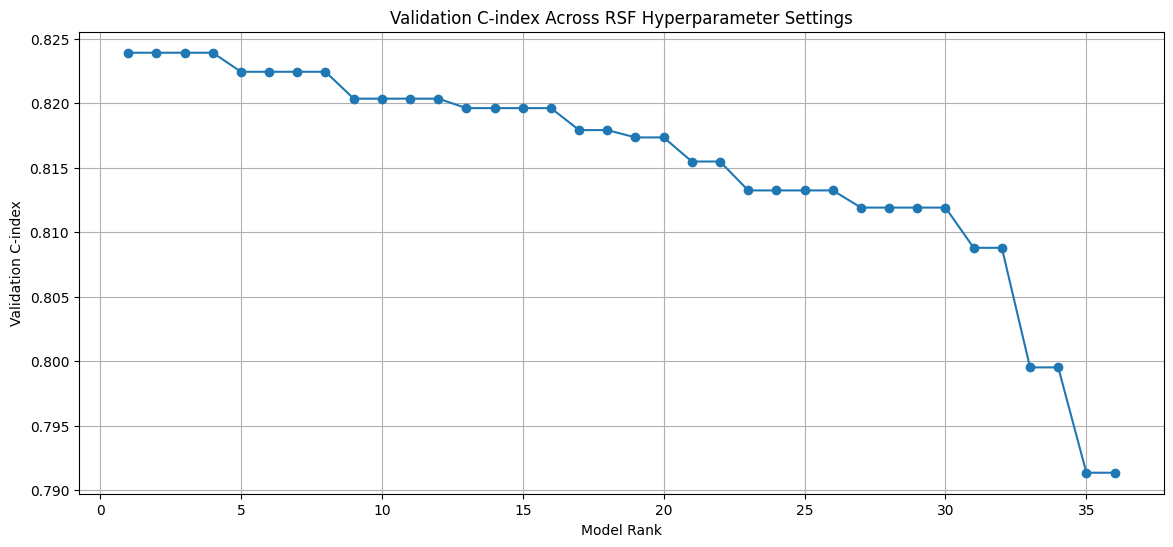

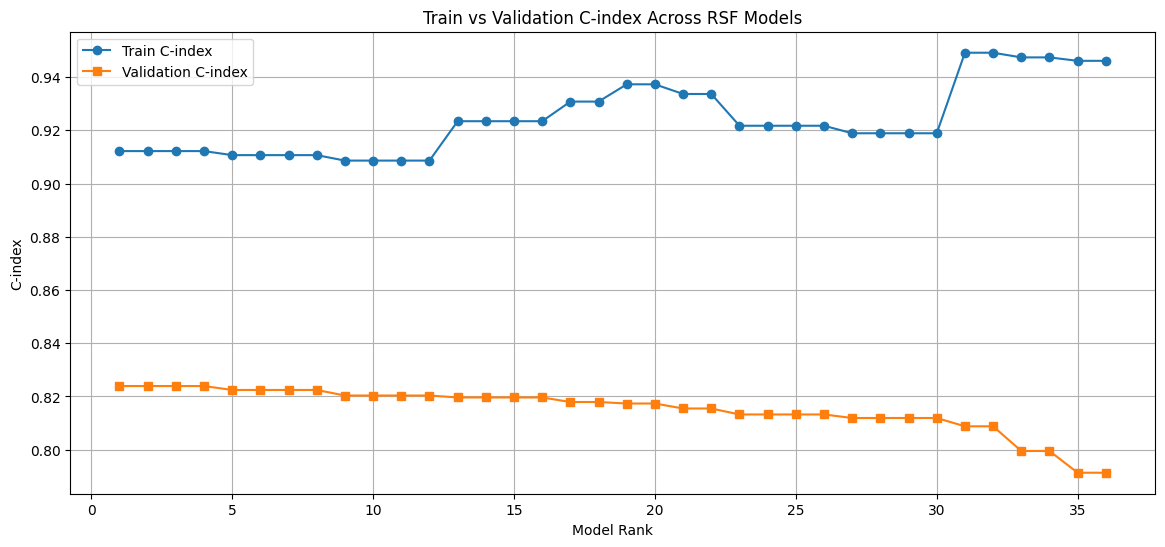

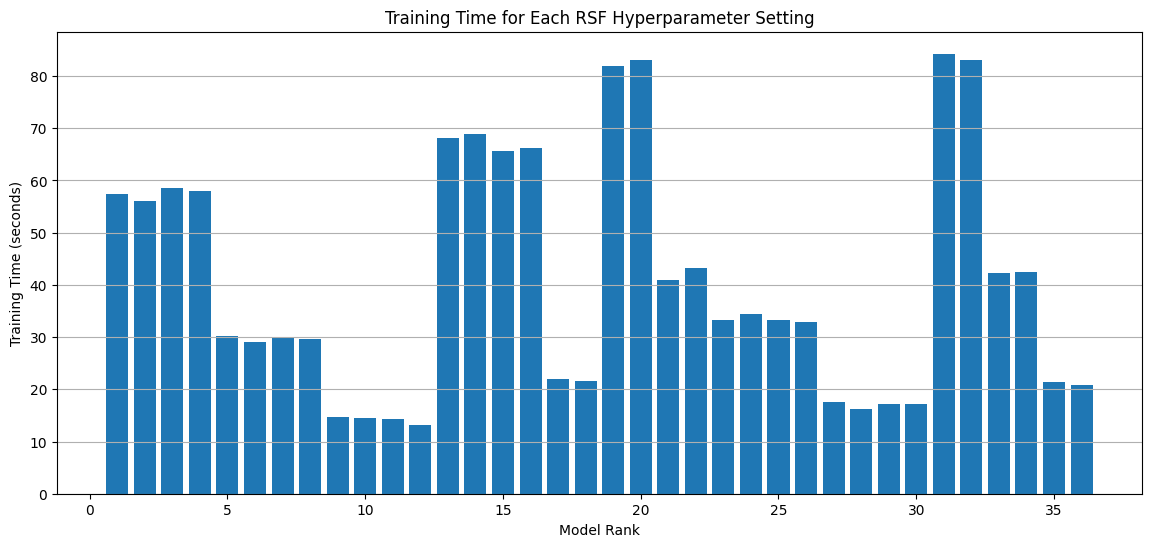

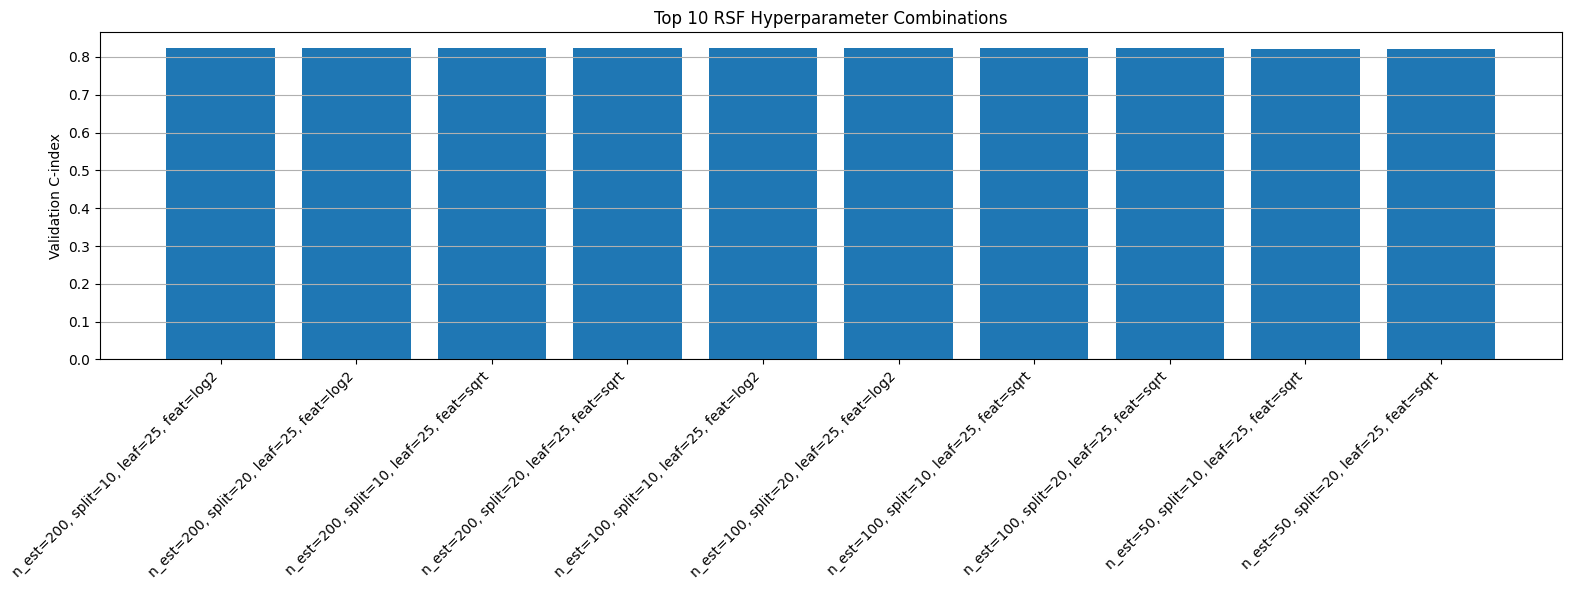


Top tuning results:
   n_estimators  min_samples_split  min_samples_leaf max_features  \
0           200                 10                25         log2   
1           200                 20                25         log2   
2           200                 10                25         sqrt   
3           200                 20                25         sqrt   
4           100                 10                25         log2   
5           100                 20                25         log2   
6           100                 10                25         sqrt   
7           100                 20                25         sqrt   
8            50                 10                25         sqrt   
9            50                 20                25         sqrt   

   train_cindex  val_cindex  oob_score   time_sec  
0      0.912183    0.823925   0.838506  57.473828  
1      0.912183    0.823925   0.838506  56.022122  
2      0.912183    0.823925   0.838506  58.533986  
3      0.91

In [10]:
import matplotlib.pyplot as plt

# =========================================================
# Step 11: Visualize tuning results
# =========================================================

# Make a readable label for each hyperparameter combination
results_df = results_df.copy()
results_df["param_label"] = results_df.apply(
    lambda row: (
        f"n_est={row['n_estimators']}, "
        f"split={row['min_samples_split']}, "
        f"leaf={row['min_samples_leaf']}, "
        f"feat={row['max_features']}"
    ),
    axis=1
)

# Sort by validation score
results_df = results_df.sort_values(by="val_cindex", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Plot 1: Validation C-index for all models
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(results_df.index + 1, results_df["val_cindex"], marker="o")
plt.xlabel("Model Rank")
plt.ylabel("Validation C-index")
plt.title("Validation C-index Across RSF Hyperparameter Settings")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Plot 2: Train vs Validation C-index
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(results_df.index + 1, results_df["train_cindex"], marker="o", label="Train C-index")
plt.plot(results_df.index + 1, results_df["val_cindex"], marker="s", label="Validation C-index")
plt.xlabel("Model Rank")
plt.ylabel("C-index")
plt.title("Train vs Validation C-index Across RSF Models")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Plot 3: Runtime per model
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.bar(results_df.index + 1, results_df["time_sec"])
plt.xlabel("Model Rank")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time for Each RSF Hyperparameter Setting")
plt.grid(True, axis="y")
plt.show()

# ---------------------------------------------------------
# Plot 4: Top 10 models by validation C-index
# ---------------------------------------------------------
top_n = min(10, len(results_df))
top_results = results_df.head(top_n)

plt.figure(figsize=(16, 6))
plt.bar(range(top_n), top_results["val_cindex"])
plt.xticks(range(top_n), top_results["param_label"], rotation=45, ha="right")
plt.ylabel("Validation C-index")
plt.title("Top 10 RSF Hyperparameter Combinations")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Display top results as table
print("\nTop tuning results:")
print(top_results[[
    "n_estimators",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
    "train_cindex",
    "val_cindex",
    "oob_score",
    "time_sec"
]])

In [11]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

import joblib

# Save model
joblib.dump(final_model, "Female_Blood_Patients_Mortality_Pred_Model.pkl")

# (Optional) Save scaler if used
# joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully")

Model saved successfully


In [12]:
# ============================================================
# DOWNLOAD TRAINED MODEL
# ============================================================
from google.colab import files
files.download("Female_Blood_Patients_Mortality_Pred_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>